In [46]:
! pip install -q langgraph langchain_openai langchain_huggingface


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
#! pip install google-generativeai

In [48]:
import google.generativeai as genai
from dotenv import load_dotenv
import os
import sys

load_dotenv()

try:
    API_KEY = os.environ["gemini_api_key"]
except KeyError:
    print("Error: The 'gemini_api_key' environment variable is not set.")
    sys.exit(1)

genai.configure(api_key=API_KEY)

model = genai.GenerativeModel(
    model_name="gemini-3-flash-preview",        
)

To determine if our email is spam or ham

In [49]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage


Define the state

In [50]:
class EmailState(TypedDict):
    email: Dict [str, Any]
    is_spam: Optional[bool]
    spam_reason: Optional[str]
    email_category: Optional[str]
    email_draft: Optional[str]
    messages: List[Dict[str, Any]]

Add Nodes and Edges

In [51]:
def read_email(state: EmailState):
    email= state["email"]
    print(f"Alfred is processing an email from {email['sender']} with subject: {email['subject']}")
    return {}

def classify_email(state: EmailState):
    email= state["email"]
    prompt =f"""As Alfred the trusted butler of Mr Wayne and his SECRET identity Batman, analyze this email carefully and determine if it is spam or legitimate.
        Email:
        From: {email['sender']}
        Subject: {email['subject']}
        Body: {email['body']}

        Answer only with 'SPAM' or 'HAM'."""

    response= model.generate_content(prompt)
    response_text= response.text.strip().lower()
    print(f"Gemini response: {response_text}")

    is_spam= response_text == "spam"

    if not is_spam:
        new_messages= state.get("messages", [])+ [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": response.text},
        ]
    else:
        new_messages= state.get("messages", [])

    return {
        "is_spam": is_spam,
        "messages": new_messages
    }

In [52]:
def handle_spam(state: EmailState):
    print(f"Alfred has marked the email as spam.")
    print("The email has been moved to the spam folder.")
    return {}

In [53]:
def draft_response(state: EmailState):
    email= state["email"]

    prompt= f"""As Alfred the butler, draft a polite preliminary response to this email.
        Email:
        From: {email['sender']}
        Subject: {email['subject']}
        Body: {email['body']}
        Draft a brief, professional response that Mr. Wayne can review and personalize before sending. """

    response= model.generate_content(prompt)

    draft_text= response.text.strip()

    new_messages= state.get("messages", [])+[
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": draft_text}
    ]

    return {
        "email_draft": draft_text,
        "messages": new_messages
    }

In [54]:
def notify_mr_wane(state: EmailState):
    email= state["email"]
    print("\n" + "-" * 50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print("\nI've prepared a draft response for your review:")
    print("-" * 50)
    print(state["email_draft"])
    print("=" * 50 + "\n")

    return {}

In [55]:
def route_email(state: EmailState) -> str:
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

In [56]:
email_graph = StateGraph(EmailState)

# Add nodes
email_graph.add_node("read_email", read_email) 
email_graph.add_node("classify_email", classify_email)  
email_graph.add_node("handle_spam", handle_spam) 
email_graph.add_node("draft_response", draft_response)  
email_graph.add_node("notify_mr_wane", notify_mr_wane)  

Routing Logic (edges)

In [57]:
email_graph.add_edge(START, "read_email")
email_graph.add_edge("read_email", "classify_email")
email_graph.add_conditional_edges("classify_email", route_email,{
    "spam": "handle_spam",
    "legitimate": "draft_response"
})

email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_wane")
email_graph.add_edge("notify_mr_wane", END)

Create state Graph

In [58]:
compiled_graph = email_graph.compile()

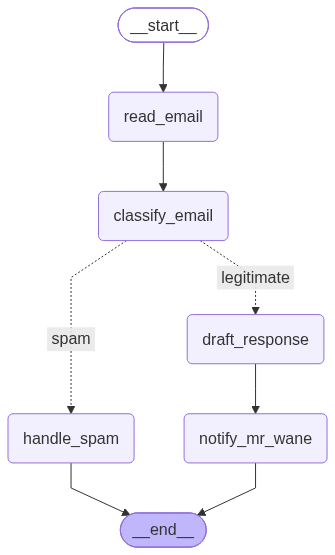

In [59]:
from IPython.display import Image, display

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

Trying different emails

In [60]:
legitimate_email ={
    "sender": "JOKER",
    "subject": "Found you Batman!",
    "body": "Mr Wane, I know that you are the Batman. I am coming to catch you very soon. JOKER"
}

spam_email= {
    "sender": "Crypto guy",
    "subject": "Best investment for 2026",
    "body": "Hello Mr Wane, I am from CC COmpany. Our crypto currency is the best investment you could make in 2026."
}
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})

print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
Alfred is processing an email from JOKER with subject: Found you Batman!
Gemini response: ham

--------------------------------------------------
Sir, you've received an email from JOKER.
Subject: Found you Batman!

I've prepared a draft response for your review:
--------------------------------------------------
Master Bruce,

I have taken the liberty of drafting a response to this rather... vibrant piece of correspondence. I have opted for a tone of polite dismissal, treating the message as the sort of harmless, if eccentric, delusion one expects when one’s name is frequently in the social columns. 

I have also taken the small liberty of subtly noting his inability to spell your surname correctly, as I find that a pointed correction often deflates the ego of the more theatrical sort of criminal.

***

**Subject: Re: Found you Batman!**

To the individual identifying as "JOKER,"

Thank you for your correspondence. Master Wayne is always intrigued to he